# Analysis of MNase-seq replication timing

March 29, 2024

Updated replication timing analysis with realigned 60 minute BAM



In [3]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [70]:
from src.mnase_replication_timing_analysis import MNaseOriginAnalysis

In [71]:
mnase_analysis = MNaseOriginAnalysis()

In [72]:
replicate = 1
chromosome = 10
mnase_analysis.load_mnase_data(replicate, chromosome)

In [73]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

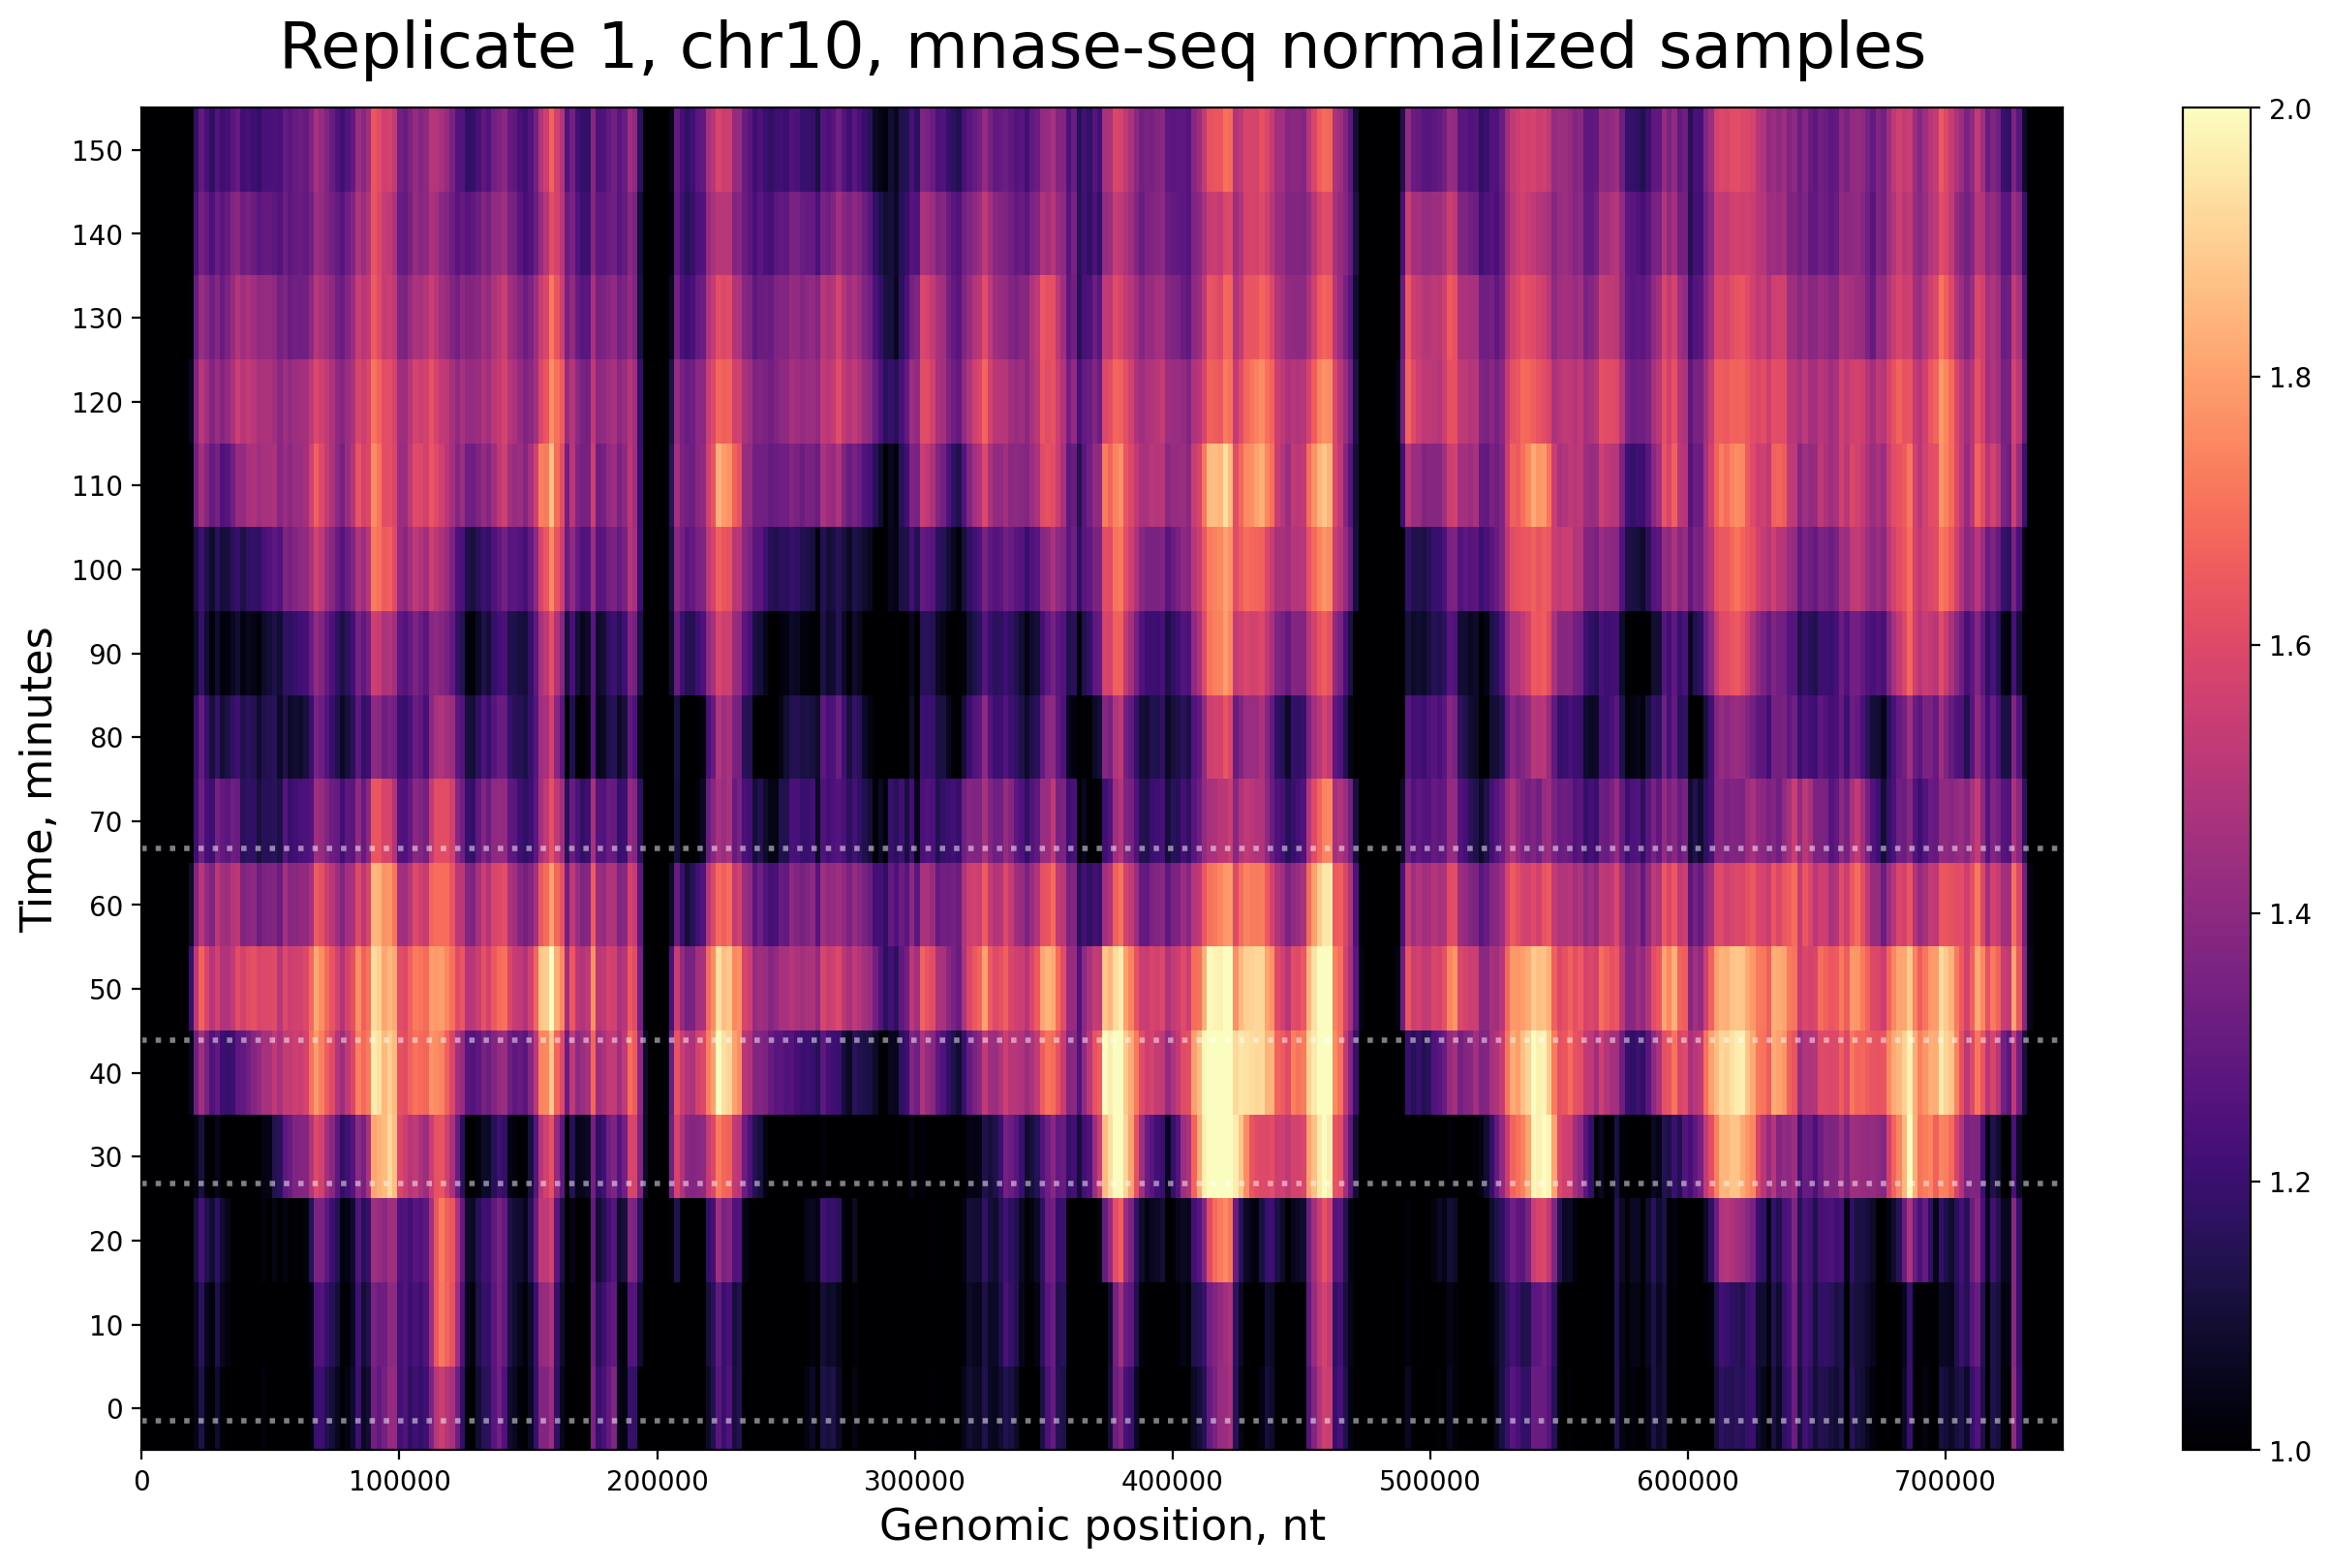

In [74]:
mnase_analysis.plot_heatmap(plot_norm_by_copy=True)

In [150]:
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

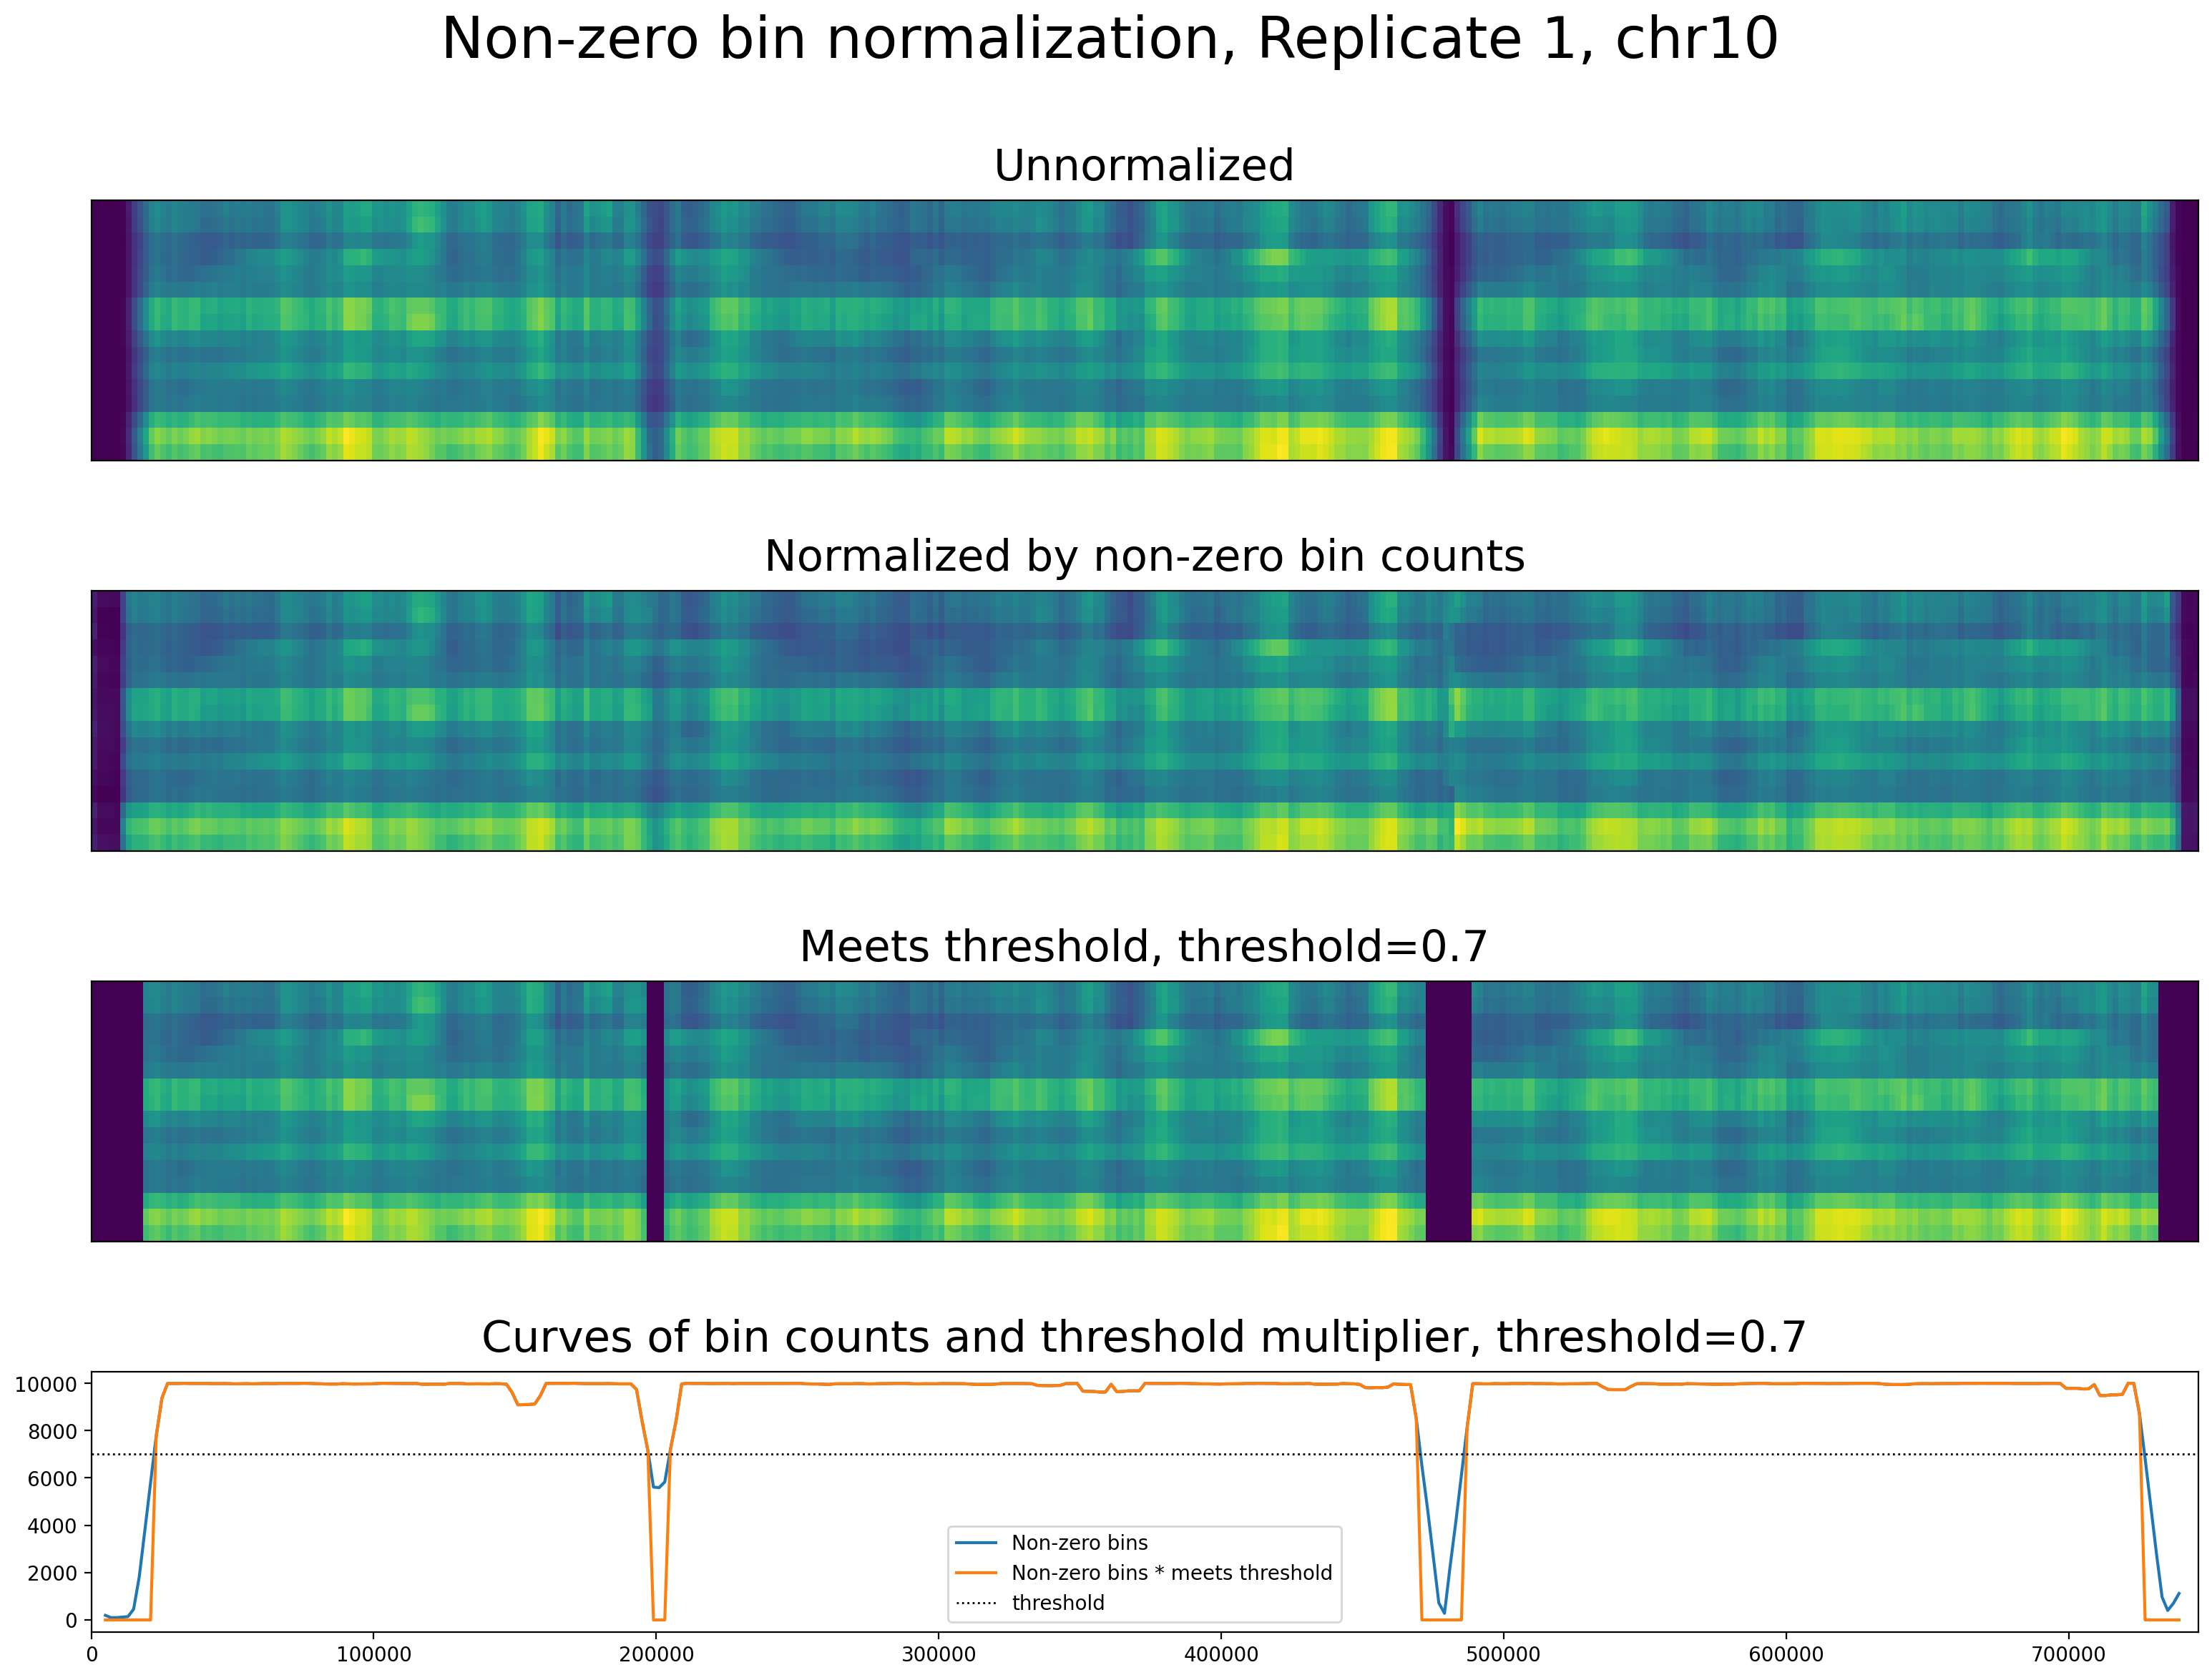

In [178]:
mnase_analysis.plot_bin_normalization_procedure()

# Compute replication profile for each gene

For each gene
1. Compute the raw replication profile
2. Compute its replication time (early/late)
3. Will need to normalize by the replicate's S phase
4. Compute the correlation with its gene expression


In [189]:
mnase_analysis = MNaseOriginAnalysis()

replicate = 1
chromosome = 1
mnase_analysis.load_mnase_data(replicate, chromosome)
mnase_analysis.compute_sliding_window_counts_all_times()
mnase_analysis.normalize_samples()

In [ ]:
bin_curves_rep1, exp_cor1 = mnase_analysis.compute_bin_curves_and_expression_correlations(replicate=1)

In [338]:
bin_curves_rep2, exp_cor2 = mnase_analysis.compute_bin_curves_and_expression_correlations(replicate=2)

1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 

Text(0, 0.5, 'Correlation, Replicate 2')

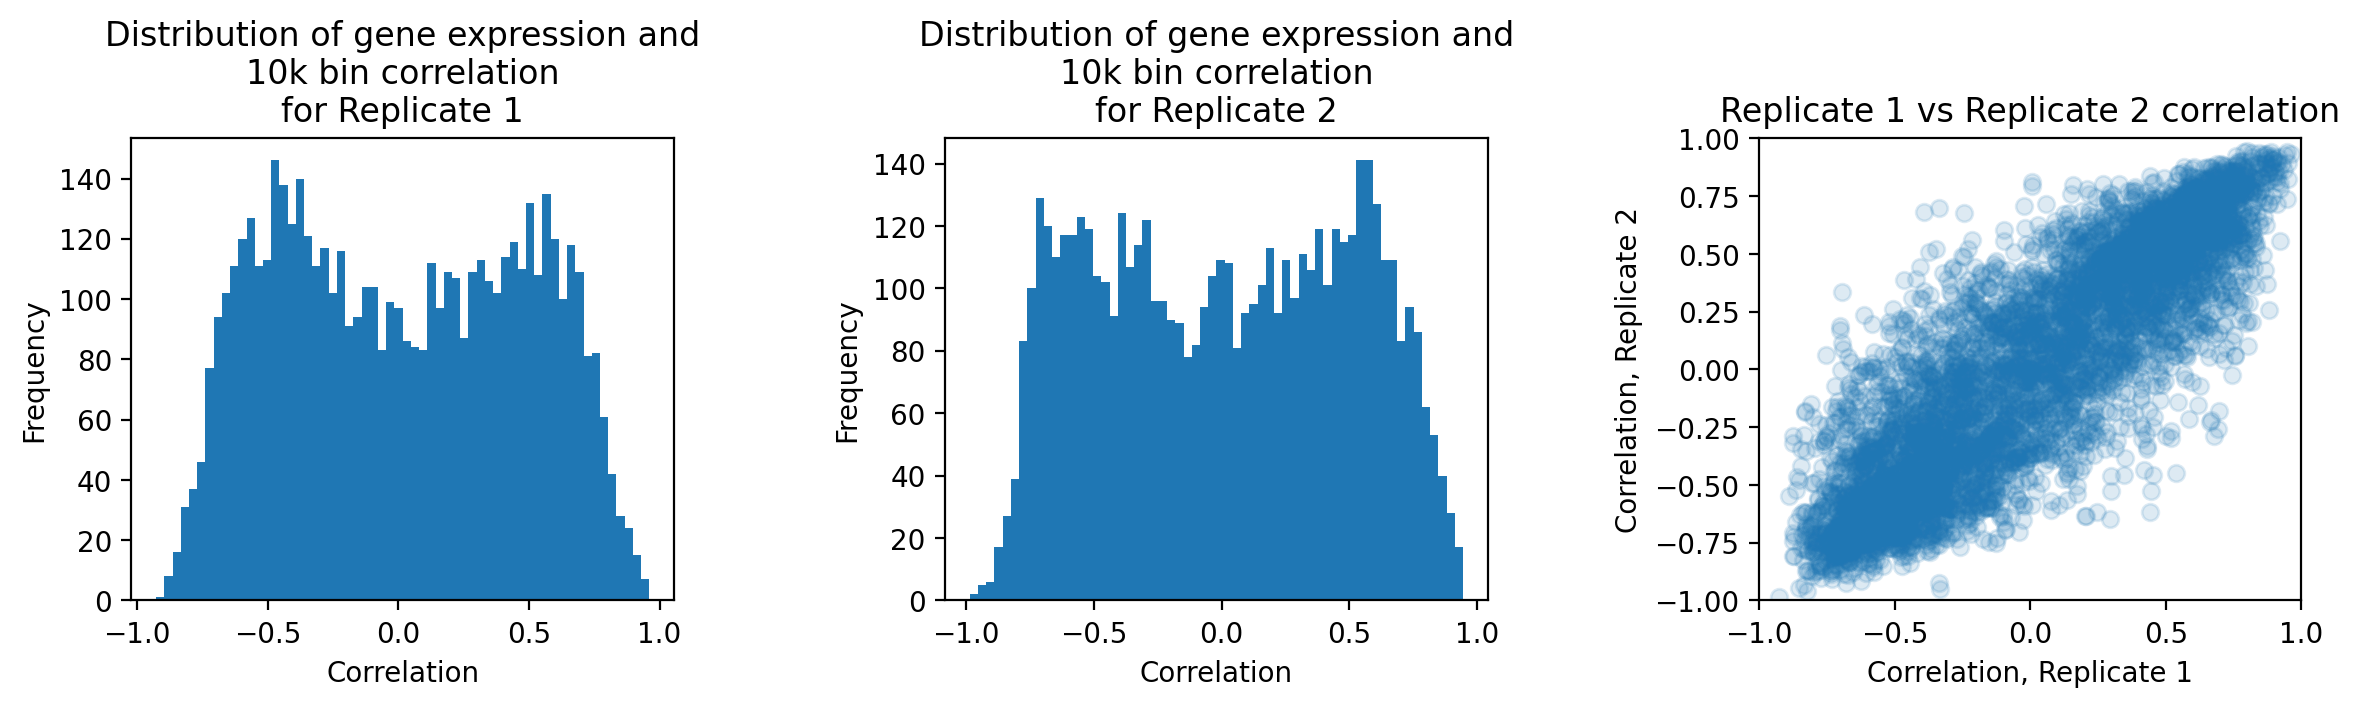

In [343]:
plt.figure(figsize=(14, 3))
plt.subplots_adjust(wspace=0.5)

plt.subplot(1, 3, 1)
plt.hist(exp_cor1.values, bins=60)
plt.title("Distribution of gene expression and\n10k bin correlation\nfor Replicate 1")
plt.xlabel("Correlation")
plt.ylabel("Frequency")

plt.subplot(1, 3, 2)
plt.hist(exp_cor2.values, bins=60)
plt.title("Distribution of gene expression and\n10k bin correlation\nfor Replicate 2")
plt.xlabel("Correlation")
plt.ylabel("Frequency")

plt.subplot(1, 3, 3)
plt.scatter(exp_cor1, exp_cor2, alpha=0.15)
plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.title("Replicate 1 vs Replicate 2 correlation")
plt.xlabel("Correlation, Replicate 1")
plt.ylabel("Correlation, Replicate 2")


# Polar Plot

Goal: Classify genes by their peak and trough gene expression
    
Separately for Mother and Daughter Cells

Output:
1. Time and phase of peak gene expression
2. Time and phase of trough gene expression


In [360]:
from src.gene_expression_deconv_analysis import GeneExpressionAnalysis

ge_analysis = GeneExpressionAnalysis(
    'output/deconvolve_combined_g_opt_2024_03_14/gene_expression/')


In [399]:
from src.peak_to_trough import compute_ptr

In [809]:
ge_analysis.compute_ptr_inds_tps()

In [868]:
selected_genes = ['DSE1', 'DSE2', 'DSE3', 'DSE4']

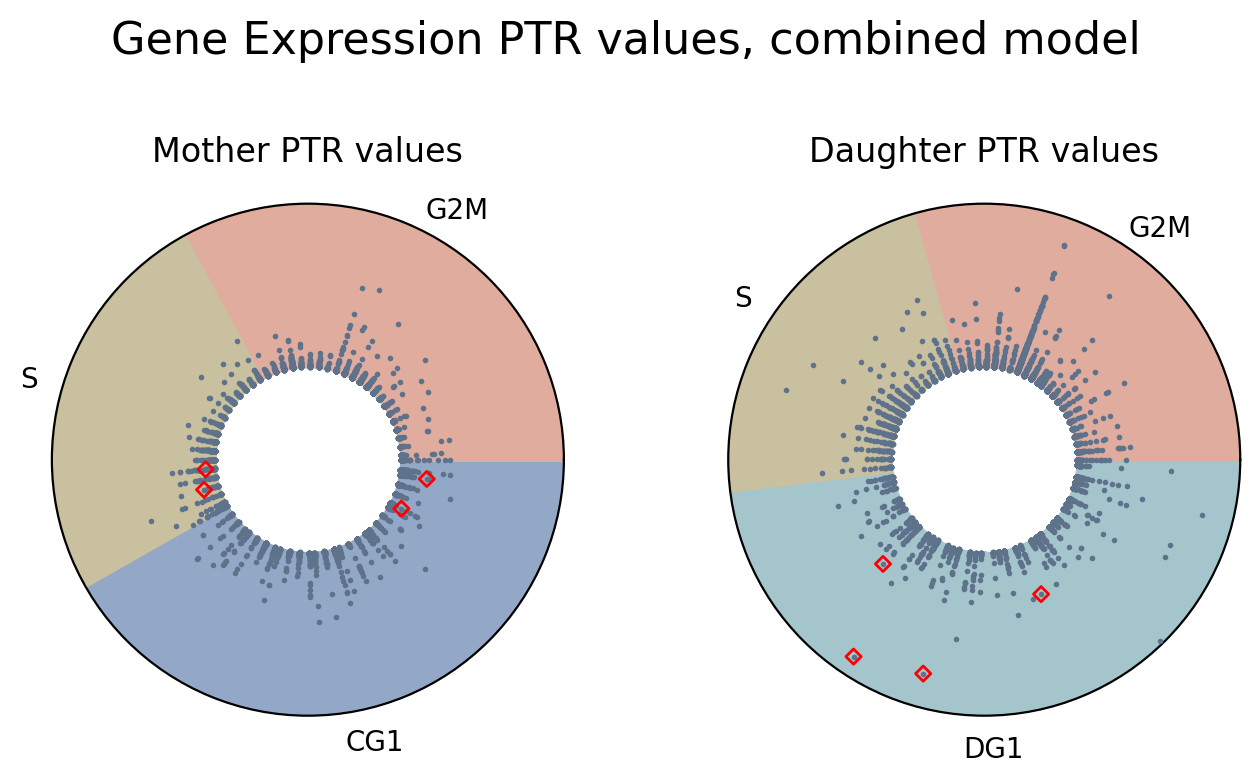

In [880]:
ge_analysis.plot_scatter_polar(selected_genes=selected_genes)